In [1]:
import sys, os
sys.path.append("../")

import jax
jax.config.update("jax_enable_x64", True)

import qmax as qx

from miscutils.plot import animate

import jax.numpy as jnp
import diffrax

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import Image

In [2]:
x0 = -10
xf = 10
num_steps = 5000
num_modes = 500

fd = qx.spaces.FiniteDifference(x0, xf, num_steps)
ps = qx.spaces.PseudoSpectral(x0, xf, num_steps, num_modes)

potential = lambda x: 0.5 * x ** 2

y1_vals = 0.1 * jnp.exp(-0.5 * (fd.x_range - 5) ** 2)
y2_vals = 0.1 * jnp.exp(-0.5 * (ps.x_range - 5) ** 2)

y_fd = fd.from_values(y1_vals)
y_ps = ps.from_values(y2_vals)

In [3]:
L1 = qx.spaces.FiniteDifferenceLaplacian(1)
L1 = L1.with_exponentiator(qx.exponentiators.ScaleSquareExponentiator())
V1 = qx.spaces.FiniteDifferencePotentialEnergy(potential)

L2 = qx.spaces.PseudoSpectralLaplacian()
V2 = qx.spaces.PseudoSpectralPotentialEnergy(potential)

In [4]:
t0 = 0.0
t1 = 4 * jnp.pi
dt = 0.01

H1 = -0.5 * L1 + V1
H2 = -0.5 * L2 + V2

sys1 = qx.system.TimeInvariantSystem(H1)
sys2 = qx.system.TimeInvariantSystem(H2)

sys1 = sys1.adapt(t0, t1, dt, y_fd, qx.timestepper.Midpoint())

%time ys1, t_range = sys1.propagate(t0, t1, dt, y_fd, qx.timestepper.Midpoint())
%time ys2, t_range = sys2.propagate(t0, t1, dt, y_ps, qx.timestepper.Midpoint())

CPU times: user 2.49 s, sys: 5.51 ms, total: 2.5 s
Wall time: 2.59 s


/home/ahmed/Documents/UCI/research/quantum_dynamics/qmax/system.py:143: UserWarning: Orders do not match: time_stepper.order=2 and op.exp_order=1, so effective order of solution is limited to min(2, 1) = 1
  self.check_consistency(time_stepper)


CPU times: user 142 ms, sys: 23.7 ms, total: 166 ms
Wall time: 205 ms


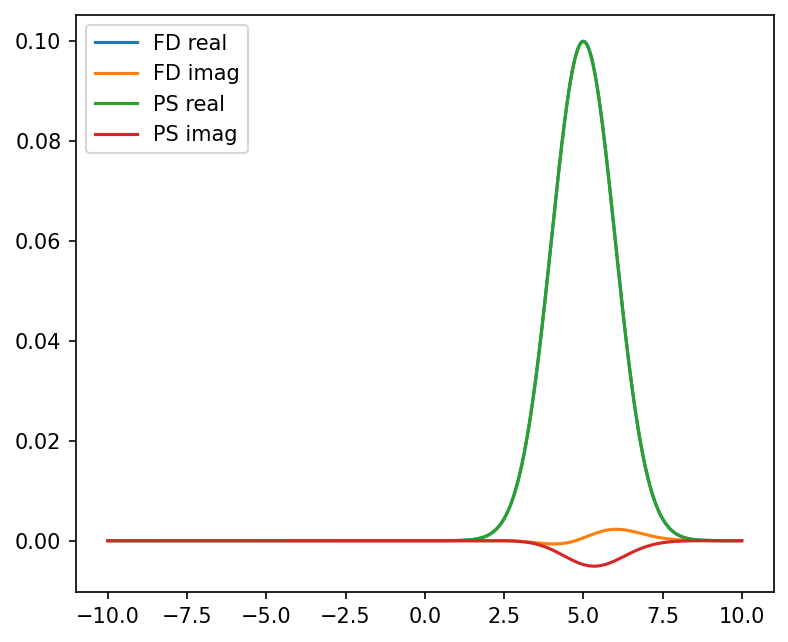

In [5]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

ax.plot(fd.x_range, jnp.real(ys1[-1].values), label="FD real")
ax.plot(fd.x_range, jnp.imag(ys1[-1].values), label="FD imag")

ax.plot(ps.x_range, jnp.real(ys2[-1].values), label="PS real")
ax.plot(ps.x_range, jnp.imag(ys2[-1].values), label="PS imag")

ax.legend()

plt.savefig("qho_ps_vs_fd.png")
plt.show()
plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

#jnp.linalg.norm(ys.values, axis=1)

ax.plot(t_range, jnp.linalg.norm(ys1.values, axis=1))
ax.plot(t_range, jnp.linalg.norm(ys2.values, axis=1))

ax.set_ylim([0, 50])

plt.show()
plt.close(fig)

In [ ]:
n = 2
num_frames =100

def func(idx, ax, state, args):
    y1_vals = ys1[n * idx].values
    y2_vals = ys2[n * idx].values

    ax.plot(fd.x_range, jnp.abs(y1_vals))
    ax.plot(ps.x_range, jnp.abs(y2_vals))

    #ax.plot(fd.x_range, jnp.imag(y_vals))

    #y_vals = ys2[-n * idx].values
    #ax.plot(space.x_range, jnp.real(y_vals))
    #ax.plot(space.x_range, jnp.imag(y_vals))
    #ax.plot(space.x_range, jnp.abs(y_vals))

    ax.set_xlim([-12, 12])
    ax.set_ylim([-2.0, 2.0])

animate(func, t_range.shape[0] // n, filename="output.gif")
Image(url="output.gif")  